<a href="https://colab.research.google.com/github/laleejyo/tensors/blob/main/Transfer_learning_in_tensorflow_part_3_scaling_up.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tranfer learning with Tensorflow3 - scalling
scalling up foodvision dataset sample

In [1]:
!nvidia-smi

Sat Jun 13 09:35:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
## creating helper funcitons
##In previous notes created series of helper functions to do different tasks, let's download them
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py


--2026-06-13 09:35:58--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-06-13 09:35:58 (123 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [3]:
## import series of helper functions for our notebook
from helper_functions import create_tensorboard_callback,plot_loss_curves,unzip_data,compare_historys,walk_through_dir


In [4]:
## 101 food clases: working with less data
## download the data set
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
from helper_functions import unzip_data
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
unzip_data("101_food_classes_10_percent.zip")

train_dir="101_food_classes_10_percent/train"
test_dir="101_food_classes_10_percent/test"

--2026-06-13 09:36:11--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py.1’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-06-13 09:36:11 (97.4 MB/s) - ‘helper_functions.py.1’ saved [10246/10246]

--2026-06-13 09:36:12--  https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 172.217.79.207, 142.250.153.207, 142.250.145.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.217.79.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
L

In [5]:
## how many images and classes are there

walk_through_dir("101_food_classes_10_percent")

There are 2 directories and 0 images in '101_food_classes_10_percent'.
There are 101 directories and 0 images in '101_food_classes_10_percent/test'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/baklava'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/paella'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/escargots'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/clam_chowder'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/dumplings'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/tacos'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/gnocchi'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/frozen_yogurt'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/lobster_roll_sandwich'.
There are 0 directories and 250 images in '101_food

In [6]:
import tensorflow as tf
IMAGE_SIZE= (224,224)
train_data_all_10_percent=tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                                              label_mode='categorical',
                                                                              image_size=IMAGE_SIZE)

test_data=tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                              label_mode='categorical',
                                                              image_size=IMAGE_SIZE,
                                                              shuffle=False
                                                              )

Found 7575 files belonging to 101 classes.
Found 25250 files belonging to 101 classes.


In [7]:
##Train a big log model with transfer learning on 10% of 101 food classes
##1.create a model checkpointcallback
##2.create a data arugumentation to build data augmentation right into the model
##3.Build headless(no top layers) funcational EfficientNetB0 backboned model(we will create outown output layer)
##4.Compile our model
##5.Feature extract for 5 full passes(5 Epochs on the train dataset and validate on 15% of the test data,to save epoach time)

##1.create a model checkpointcallback
checkpoint_path="101_classes_10_percent_data_model_checkpoint.weights.h5"
checkpoint_callback=tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                       save_weights_only=True,
                                                       monitor="val_accuracy",
                                                       save_best_only=True)

In [8]:
##create a data augmentation layer to incorporate it right to the model
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential # Corrected typos: fensorflow -> tensorflow, kearas -> keras, modules -> models

#setup data augmentation
data_augmentation=Sequential(
    [
        layers.RandomFlip("horizontal"), # Use layers directly
        layers.RandomRotation(0.2),
        layers.RandomHeight(0.2),
        layers.RandomWidth(0.2),
        layers.RandomZoom(0.2),
        layers.RandomBrightness(0.2), # Corrected layer name, was `Random(brightness=0.2)`
        layers.RandomContrast(0.2)
    ],name="data_augmentation"
)

In [9]:
# Setup base model and freeze its layers (this will extract features)
base_model = tf.keras.applications.efficientnet.EfficientNetB0(include_top=False)
base_model.trainable = False

# Setup model architecture with trainable top layers
inputs = layers.Input(shape=(224, 224, 3), name="input_layer") # shape of input image
x = data_augmentation(inputs) # augment images (only happens during training)
x = base_model(x, training=False) # put the base model in inference mode so we can use it to extract features without updating the weights
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x) # pool the outputs of the base model
outputs = layers.Dense(len(train_data_all_10_percent.class_names), activation="softmax", name="output_layer")(x) # same number of outputs as classes
model = tf.keras.Model(inputs, outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [10]:
# Get a summary of our model
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 101)            │       129,381 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,178,952 (15.94 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [11]:
# Compile
model.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(), # use Adam with default settings
              metrics=["accuracy"])

# Fit
history_all_classes_10_percent = model.fit(train_data_all_10_percent,
                                           epochs=5, # fit for 5 epochs to keep experiments quick
                                           validation_data=test_data,
                                           validation_steps=int(0.15 * len(test_data)), # evaluate on smaller portion of test data
                                           callbacks=[checkpoint_callback]) # save best model weights to file

Epoch 1/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 57s 171ms/step - accuracy: 0.2459 - loss: 3.4628 - val_accuracy: 0.4213 - val_loss: 2.6394
Epoch 2/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 74s 161ms/step - accuracy: 0.4619 - loss: 2.3434 - val_accuracy: 0.4918 - val_loss: 2.1530
Epoch 3/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 38s 162ms/step - accuracy: 0.5250 - loss: 1.9831 - val_accuracy: 0.5215 - val_loss: 1.9558
Epoch 4/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 38s 160ms/step - accuracy: 0.5633 - loss: 1.7960 - val_accuracy: 0.5267 - val_loss: 1.8826
Epoch 5/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 37s 157ms/step - accuracy: 0.5985 - loss: 1.6276 - val_accuracy: 0.5140 - val_loss: 1.8704


In [12]:
# Evaluate model
results_feature_extraction_model = model.evaluate(test_data)
results_feature_extraction_model

790/790 ━━━━━━━━━━━━━━━━━━━━ 61s 78ms/step - accuracy: 0.5745 - loss: 1.6174


[1.6174136400222778, 0.5744950771331787]

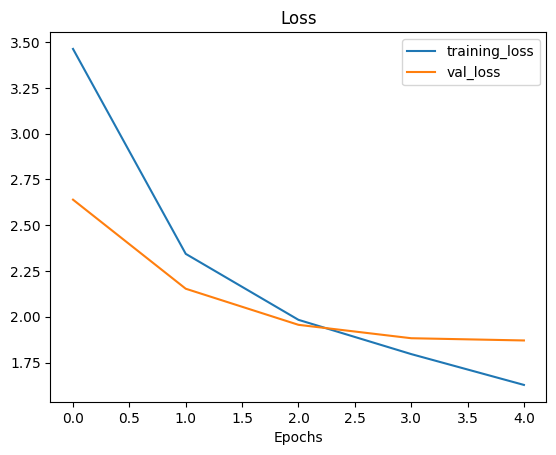

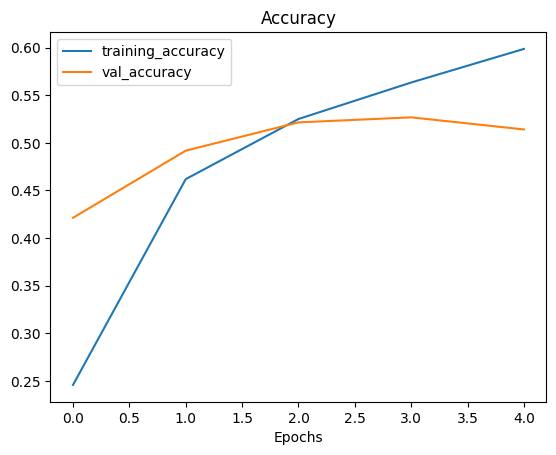

In [13]:
plot_loss_curves(history_all_classes_10_percent)

In [14]:
# Unfreeze all of the layers in the base model
base_model.trainable = True

# Refreeze every layer except for the last 5
for layer in base_model.layers[:-5]:
  layer.trainable = False

In [15]:
# Recompile model with lower learning rate
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(1e-4), # 10x lower learning rate than default
              metrics=['accuracy'])

In [16]:
# What layers in the model are trainable?
for layer in model.layers:
  print(layer.name, layer.trainable)

input_layer True
data_augmentation True
efficientnetb0 True
global_average_pooling True
output_layer True


In [17]:
# Check which layers are trainable
for layer_number, layer in enumerate(base_model.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer False
1 rescaling False
2 normalization False
3 rescaling_1 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeeze Fals

In [18]:
# Fine-tune for 5 more epochs
fine_tune_epochs = 10 # model has already done 5 epochs, this is the total number of epochs we're after (5+5=10)

history_all_classes_10_percent_fine_tune = model.fit(train_data_all_10_percent,
                                                     epochs=fine_tune_epochs,
                                                     validation_data=test_data,
                                                     validation_steps=int(0.15 * len(test_data)), # validate on 15% of the test data
                                                     initial_epoch=history_all_classes_10_percent.epoch[-1]) # start from previous last epoch

Epoch 5/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 52s 169ms/step - accuracy: 0.6195 - loss: 1.5668 - val_accuracy: 0.5445 - val_loss: 1.7715
Epoch 6/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 41s 173ms/step - accuracy: 0.6491 - loss: 1.4186 - val_accuracy: 0.5561 - val_loss: 1.7120
Epoch 7/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 38s 158ms/step - accuracy: 0.6648 - loss: 1.3546 - val_accuracy: 0.5704 - val_loss: 1.6794
Epoch 8/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 37s 157ms/step - accuracy: 0.6829 - loss: 1.2717 - val_accuracy: 0.5728 - val_loss: 1.6738
Epoch 9/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 37s 158ms/step - accuracy: 0.6936 - loss: 1.2168 - val_accuracy: 0.5794 - val_loss: 1.6340
Epoch 10/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 37s 156ms/step - accuracy: 0.7048 - loss: 1.1652 - val_accuracy: 0.5742 - val_loss: 1.6288


In [19]:
# Evaluate fine-tuned model on the whole test dataset
results_all_classes_10_percent_fine_tune = model.evaluate(test_data)
results_all_classes_10_percent_fine_tune

790/790 ━━━━━━━━━━━━━━━━━━━━ 61s 77ms/step - accuracy: 0.6166 - loss: 1.4284


[1.428444266319275, 0.6165544390678406]

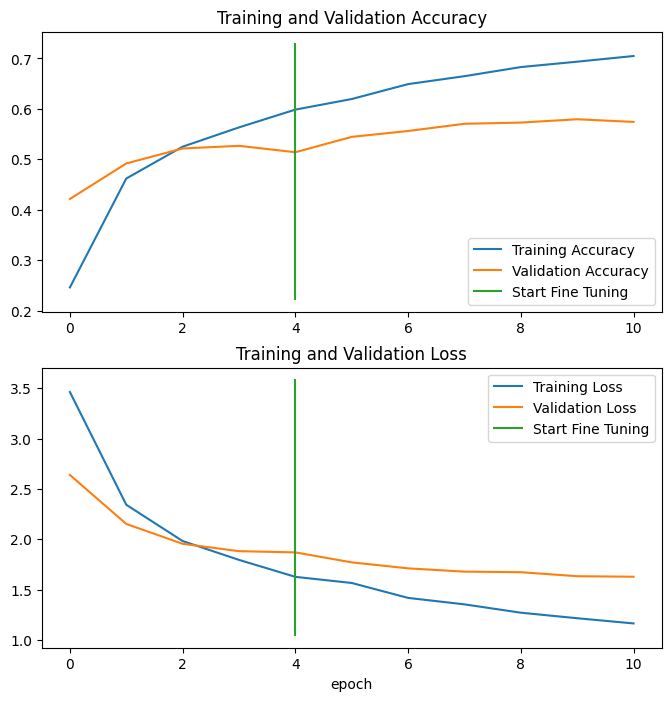

In [20]:
compare_historys(original_history=history_all_classes_10_percent,
                 new_history=history_all_classes_10_percent_fine_tune,
                 initial_epochs=5)

In [22]:
import tensorflow as tf

# Download pre-trained model from Google Storage (like a cooking show, I trained this model earlier, so the results may be different than above)
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/06_101_food_class_10_percent_saved_big_dog_model.zip
saved_model_path = "06_101_food_class_10_percent_saved_big_dog_model.zip"
unzip_data(saved_model_path)

# Note: loading a model will output a lot of 'WARNINGS', these can be ignored: https://www.tensorflow.org/tutorials/keras/save_and_load#save_checkpoints_during_training
# There's also a thread on GitHub trying to fix these warnings: https://github.com/tensorflow/tensorflow/issues/40166
# model = tf.keras.models.load_model("drive/My Drive/tensorflow_course/101_food_class_10_percent_saved_big_dog_model/") # path to drive model
#model = tf.keras.models.load_model(saved_model_path.split(".")[0]) # don't include ".zip" in loaded model path

--2026-06-13 09:54:22--  https://storage.googleapis.com/ztm_tf_course/food_vision/06_101_food_class_10_percent_saved_big_dog_model.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 172.217.79.207, 142.250.153.207, 142.250.145.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.217.79.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 46760742 (45M) [application/zip]
Saving to: ‘06_101_food_class_10_percent_saved_big_dog_model.zip.1’

06_101_food_class_1 100%[===================>]  44.59M  27.9MB/s    in 1.6s    

2026-06-13 09:54:24 (27.9 MB/s) - ‘06_101_food_class_10_percent_saved_big_dog_model.zip.1’ saved [46760742/46760742]



In [23]:
unzip_data("/content/06_101_food_class_10_percent_saved_big_dog_model.zip.1")

In [26]:
import tensorflow as tf

# load in saved model using TFSMLayer for Keras 3 compatibility with SavedModel format
# The traceback suggests `keras.layers.TFSMLayer(/content/06_101_food_class_10_percent_saved_big_dog_model, call_endpoint='serving_default')`
# We wrap it in a functional model to maintain compatibility with a 'model' object.
# Note: This loads the model as an inference-only layer.
loaded_sm_layer = tf.keras.layers.TFSMLayer("/content/06_101_food_class_10_percent_saved_big_dog_model", call_endpoint='serving_default')

# To use it as a Keras model, you can wrap it (e.g., if you need to use .predict() directly on it).
# If your original model had a specific input shape, you might need to define it here.
# Assuming the input shape is (None, 224, 224, 3) as per previous cells.
inputs = tf.keras.Input(shape=(224, 224, 3))
outputs = loaded_sm_layer(inputs)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# You can also load the original model if it was saved in .keras or .h5 format, or if you switch to Keras 2.
# This specific error indicates an incompatibility with Keras 3 and SavedModel via load_model().
# For example, if it was saved as .keras:
# model = tf.keras.models.load_model("/content/06_101_food_class_10_percent_saved_big_dog_model.keras")


In [29]:
# Evalute the loaded model (the one which we downloaded on test data)

# The loaded model needs to be compiled before evaluation.
model.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

results_downloaded_models=model.evaluate(test_data)
results_downloaded_models

790/790 ━━━━━━━━━━━━━━━━━━━━ 70s 70ms/step - accuracy: 0.6078 - loss: 1.7986


[1.7985960245132446, 0.6077623963356018]

Making predictions with trained model


In [30]:
preds_probs=model.predict(test_data,verbose=1)#set verbosity to see how long it left

790/790 ━━━━━━━━━━━━━━━━━━━━ 59s 68ms/step


In [31]:
len(test_data)

790

In [32]:
790*32. # Batch size


25280

In [33]:
## how many predictions are there
len(preds_probs)

1

In [36]:
#what is shape of our predictions
# Access the prediction array from the dictionary
preds_probs['dense_8'].shape

(25250, 101)

In [38]:
# let's see how first 10 predictions looks like
preds_probs['dense_8'][:10]

array([[5.9542045e-02, 3.5742307e-06, 4.1377075e-02, ..., 1.4138729e-09,
        8.3531515e-05, 3.0897558e-03],
       [9.6401697e-01, 1.3753328e-09, 8.4780628e-04, ..., 5.4286898e-05,
        7.8362082e-12, 9.8465858e-10],
       [9.5925879e-01, 3.2533928e-05, 1.4866977e-03, ..., 7.1891617e-07,
        5.4397839e-07, 4.0276122e-05],
       ...,
       [4.7313228e-01, 1.2931248e-07, 1.4805590e-03, ..., 5.9750368e-04,
        6.6969369e-05, 2.3469483e-05],
       [4.4571877e-02, 4.7266042e-07, 1.2258447e-01, ..., 6.3498956e-06,
        7.5318903e-06, 3.6779128e-03],
       [7.2438896e-01, 1.9249864e-09, 5.2310996e-05, ..., 1.2291438e-03,
        1.5792790e-09, 9.6395757e-05]], dtype=float32)

In [43]:
# what does the first prediction probability array look like
preds_probs['dense_8'][0],len(preds_probs['dense_8'][0]),sum(preds_probs['dense_8'][0])

(array([5.9542045e-02, 3.5742307e-06, 4.1377075e-02, 1.0660733e-09,
        8.1615177e-09, 8.6640606e-09, 8.0927788e-07, 8.5652874e-07,
        1.9859139e-05, 8.0977958e-07, 3.1728153e-09, 9.8675207e-07,
        2.8532313e-04, 7.8049606e-10, 7.4230414e-04, 3.8916627e-05,
        6.4740966e-06, 2.4977483e-06, 3.7891405e-05, 2.0678320e-07,
        1.5538608e-05, 8.1507608e-07, 2.6230659e-06, 2.0010830e-07,
        8.3827985e-07, 5.4216425e-06, 3.7391164e-06, 1.3150602e-08,
        2.7761550e-03, 2.8051880e-05, 6.8563311e-10, 2.5574942e-05,
        1.6688938e-04, 7.6408280e-10, 4.0452974e-04, 1.3150804e-08,
        1.7957456e-06, 1.4448334e-06, 2.3062978e-02, 8.2467460e-07,
        8.5366145e-07, 1.7138753e-06, 7.0525807e-06, 1.8402300e-08,
        2.8553640e-07, 7.9483571e-06, 2.0681839e-06, 1.8525392e-07,
        3.3619820e-08, 3.1522752e-04, 1.0410959e-05, 8.5449722e-07,
        8.4741831e-01, 1.0555461e-05, 4.4094944e-07, 3.7404418e-05,
        3.5306548e-05, 3.2489243e-05, 6.7314650e

In [ ]:
# prediction of probability per class(in our cases 101 predictions)
print(f"The predictions probabilities for the sample 0:{len(preds_prob[0])} ")
print(f"what prediction probability sample 0 looks like:\n {preds_prod[0]}")
print(f"The class with the highest probability by the model for sample 0:{preds_prod[0].argmax()}")